# CIFAR-10 CNN Classifier
Three-block convolutional network with in-model data augmentation, batch normalisation, and dropout.
**Reported test accuracy: ~88.4 %**

## 1 — Imports

In [1]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import pandas as pd

from keras.models import Model
from keras.layers import (
    Input, Dense, Flatten, Conv2D, MaxPooling2D, Dropout,
    BatchNormalization, RandomFlip, RandomTranslation,
)
from keras.datasets import cifar10
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

LABELS = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

## 2 — Architecture Diagram

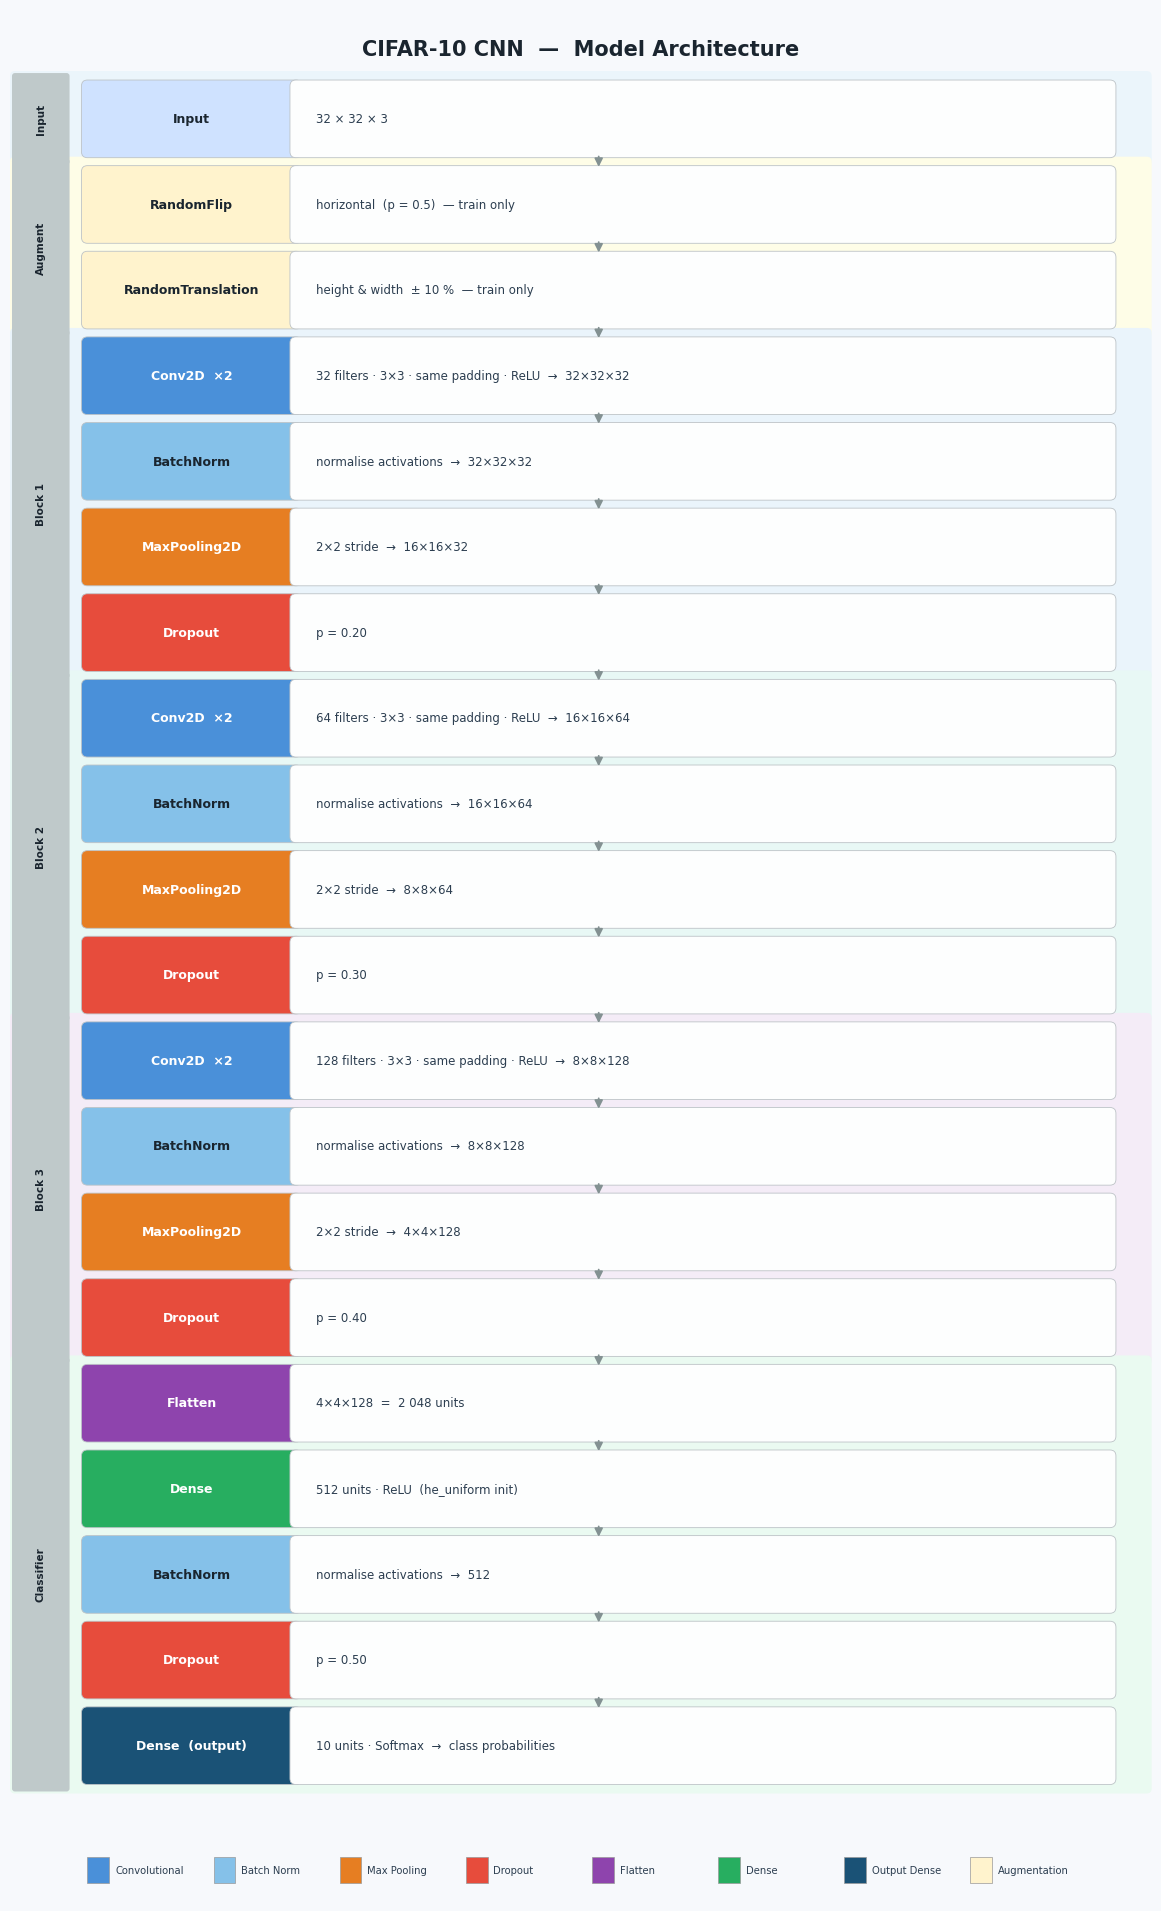

In [2]:
C_INPUT  = "#CFE2FF"
C_AUG    = "#FFF3CD"
C_CONV   = "#4A90D9"
C_BN     = "#85C1E9"
C_POOL   = "#E67E22"
C_DROP   = "#E74C3C"
C_FLAT   = "#8E44AD"
C_DENSE  = "#27AE60"
C_OUT    = "#1A5276"

LIGHT_BOXES = {C_INPUT, C_AUG, C_BN}

C_GROUP_BG = {
    "Input":      "#EBF5FB",
    "Augment":    "#FEFDE7",
    "Block 1":    "#EAF4FB",
    "Block 2":    "#E8F8F5",
    "Block 3":    "#F4ECF7",
    "Classifier": "#EAFAF1",
}

LAYERS = [
    ("Input",             "32 × 32 × 3",                                               C_INPUT, "Input"),
    ("RandomFlip",        "horizontal  (p = 0.5)  — train only",                        C_AUG,   "Augment"),
    ("RandomTranslation", "height & width  ± 10 %  — train only",                       C_AUG,   "Augment"),
    ("Conv2D  ×2",        "32 filters · 3×3 · same padding · ReLU  →  32×32×32",       C_CONV,  "Block 1"),
    ("BatchNorm",         "normalise activations  →  32×32×32",                         C_BN,    "Block 1"),
    ("MaxPooling2D",      "2×2 stride  →  16×16×32",                                   C_POOL,  "Block 1"),
    ("Dropout",           "p = 0.20",                                                   C_DROP,  "Block 1"),
    ("Conv2D  ×2",        "64 filters · 3×3 · same padding · ReLU  →  16×16×64",       C_CONV,  "Block 2"),
    ("BatchNorm",         "normalise activations  →  16×16×64",                         C_BN,    "Block 2"),
    ("MaxPooling2D",      "2×2 stride  →  8×8×64",                                     C_POOL,  "Block 2"),
    ("Dropout",           "p = 0.30",                                                   C_DROP,  "Block 2"),
    ("Conv2D  ×2",        "128 filters · 3×3 · same padding · ReLU  →  8×8×128",       C_CONV,  "Block 3"),
    ("BatchNorm",         "normalise activations  →  8×8×128",                          C_BN,    "Block 3"),
    ("MaxPooling2D",      "2×2 stride  →  4×4×128",                                    C_POOL,  "Block 3"),
    ("Dropout",           "p = 0.40",                                                   C_DROP,  "Block 3"),
    ("Flatten",           "4×4×128  =  2 048 units",                                   C_FLAT,  "Classifier"),
    ("Dense",             "512 units · ReLU  (he_uniform init)",                        C_DENSE, "Classifier"),
    ("BatchNorm",         "normalise activations  →  512",                              C_BN,    "Classifier"),
    ("Dropout",           "p = 0.50",                                                   C_DROP,  "Classifier"),
    ("Dense  (output)",   "10 units · Softmax  →  class probabilities",                C_OUT,   "Classifier"),
]

FIG_W   = 11.5
ROW_H   = 0.66
GAP     = 0.20
LEFT    = 0.78
BOX_W   = 10.30
LABEL_W = 2.10
GRP_X   = 0.05
GRP_W   = 0.52

n_rows  = len(LAYERS)
FIG_H   = n_rows * (ROW_H + GAP) + 1.80

def yc(i):
    return FIG_H - 1.10 - i * (ROW_H + GAP)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.set_xlim(0, FIG_W)
ax.set_ylim(0, FIG_H)
ax.axis("off")
fig.patch.set_facecolor("#F7F9FC")
ax.set_facecolor("#F7F9FC")

ax.text(FIG_W / 2, FIG_H - 0.40,
        "CIFAR-10 CNN  —  Model Architecture",
        ha="center", va="center", fontsize=15, fontweight="bold", color="#1A252F")
ax.text(FIG_W / 2, FIG_H - 0.78,
        "3 convolutional blocks  ·  in-model data augmentation  ·  "
        "batch normalisation  ·  he_uniform init",
        ha="center", va="center", fontsize=8.5, color="#566573")

group_rows: dict[str, list[int]] = {}
for i, (*_, grp) in enumerate(LAYERS):
    group_rows.setdefault(grp, []).append(i)

for grp, rows in group_rows.items():
    top    = yc(rows[0])  + ROW_H / 2 + GAP / 2
    bottom = yc(rows[-1]) - ROW_H / 2 - GAP / 2
    height = top - bottom
    ax.add_patch(FancyBboxPatch(
        (GRP_X, bottom), FIG_W - GRP_X - 0.05, height,
        boxstyle="round,pad=0.05", linewidth=0,
        facecolor=C_GROUP_BG[grp], zorder=0,
    ))
    ax.add_patch(FancyBboxPatch(
        (GRP_X, bottom), GRP_W, height,
        boxstyle="round,pad=0.03", linewidth=0,
        facecolor="#BFC9CA", zorder=1,
    ))
    ax.text(GRP_X + GRP_W / 2, bottom + height / 2, grp,
            ha="center", va="center", fontsize=7.5, fontweight="bold",
            color="#1A252F", rotation=90, zorder=2)

for i, (name, annot, color, _) in enumerate(LAYERS):
    cy = yc(i)
    yt = cy - ROW_H / 2
    text_color = "#1A252F" if color in LIGHT_BOXES else "white"
    ax.add_patch(FancyBboxPatch(
        (LEFT, yt), LABEL_W, ROW_H,
        boxstyle="round,pad=0.06", linewidth=0.6,
        edgecolor="#BDC3C7", facecolor=color, zorder=3,
    ))
    ax.text(LEFT + LABEL_W / 2, cy, name,
            ha="center", va="center", fontsize=9, fontweight="bold",
            color=text_color, zorder=4)
    ann_left = LEFT + LABEL_W
    ann_w    = BOX_W - LABEL_W
    ax.add_patch(FancyBboxPatch(
        (ann_left, yt), ann_w, ROW_H,
        boxstyle="round,pad=0.06", linewidth=0.6,
        edgecolor="#BDC3C7", facecolor="#FDFEFE", zorder=3,
    ))
    ax.text(ann_left + 0.20, cy, annot,
            ha="left", va="center", fontsize=8.5, color="#2C3E50", zorder=4)

arrow_x = LEFT + BOX_W / 2
for i in range(n_rows - 1):
    y_tail = yc(i)     - ROW_H / 2 - 0.02
    y_head = yc(i + 1) + ROW_H / 2 + 0.02
    ax.annotate("",
                xy=(arrow_x, y_head), xytext=(arrow_x, y_tail),
                arrowprops=dict(arrowstyle="-|>", color="#839192",
                                lw=1.3, mutation_scale=12),
                zorder=5)

legend_defs = [
    (C_CONV,  "Convolutional"),
    (C_BN,    "Batch Norm"),
    (C_POOL,  "Max Pooling"),
    (C_DROP,  "Dropout"),
    (C_FLAT,  "Flatten"),
    (C_DENSE, "Dense"),
    (C_OUT,   "Output Dense"),
    (C_AUG,   "Augmentation"),
]
lx, ly = LEFT, 0.18
for k, (c, label) in enumerate(legend_defs):
    px = lx + k * 1.27
    ax.add_patch(mpatches.Rectangle((px, ly), 0.22, 0.26, facecolor=c, zorder=5,
                                    linewidth=0.5, edgecolor="#999"))
    ax.text(px + 0.28, ly + 0.13, label,
            va="center", fontsize=7.2, color="#2C3E50", zorder=6)

plt.tight_layout(pad=0.3)
plt.savefig("model_plot.png", dpi=160, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## 3 — Load & Preprocess Data

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype('float32') / 255
x_test  = x_test.astype('float32')  / 255

y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test,  10)

print(f"Train: {x_train.shape}  |  Test: {x_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Train: (50000, 32, 32, 3)  |  Test: (10000, 32, 32, 3)


### Sample images

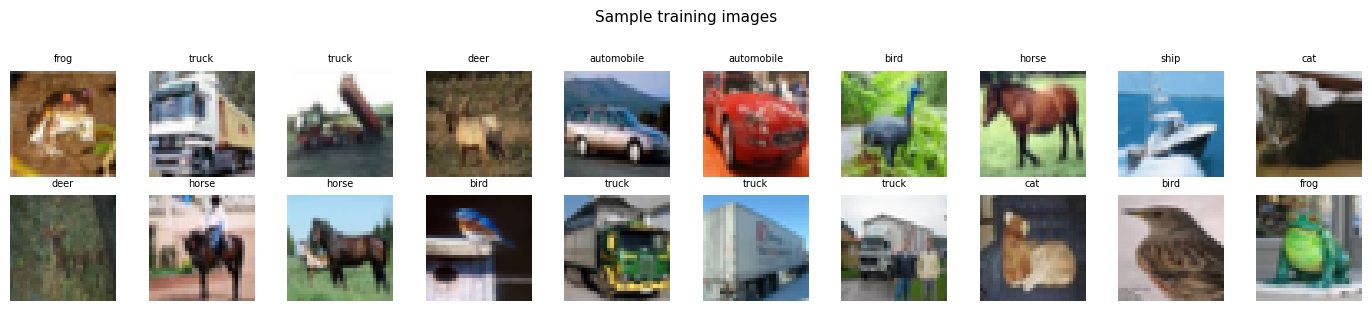

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(LABELS[np.argmax(y_train[i])], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample training images', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 4 — Build Model

In [5]:
def build_model():
    init = 'he_uniform'
    inputs = Input(shape=(32, 32, 3))

    x = RandomFlip('horizontal')(inputs)
    x = RandomTranslation(height_factor=0.1, width_factor=0.1)(x)

    x = Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer=init)(x)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3, 3), padding='same', activation='relu', kernel_initializer=init)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.2)(x)

    x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_initializer=init)(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), padding='same', activation='relu', kernel_initializer=init)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.3)(x)

    x = Conv2D(128, (3, 3), padding='same', activation='relu', kernel_initializer=init)(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), padding='same', activation='relu', kernel_initializer=init)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.4)(x)

    x = Flatten()(x)
    x = Dense(512, activation='relu', kernel_initializer=init)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(10, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,345,066 (5.13 MB)

 Trainable params: 1,343,146 (5.12 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 5 — Train

In [6]:
EPOCHS     = 40
BATCH_SIZE = 64

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
]

history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose='auto'
)

Epoch 1/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.4069 - loss: 1.7632 - val_accuracy: 0.5592 - val_loss: 1.2172 - learning_rate: 0.0010
Epoch 2/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.5673 - loss: 1.2082 - val_accuracy: 0.6097 - val_loss: 1.1218 - learning_rate: 0.0010
Epoch 3/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6377 - loss: 1.0243 - val_accuracy: 0.6858 - val_loss: 0.8913 - learning_rate: 0.0010
Epoch 4/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.6745 - loss: 0.9213 - val_accuracy: 0.7045 - val_loss: 0.8681 - learning_rate: 0.0010
Epoch 5/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.7051 - loss: 0.8431 - val_accuracy: 0.7266 - val_loss: 0.7888 - learning_rate: 0.0010
Epoch 6/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.7245 - loss: 0.7912 - val_accuracy: 0.7474 - val_loss: 0.7188 - learning_rate: 0.0010
Epoch 7/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.7414 - l

## 6 — Training History

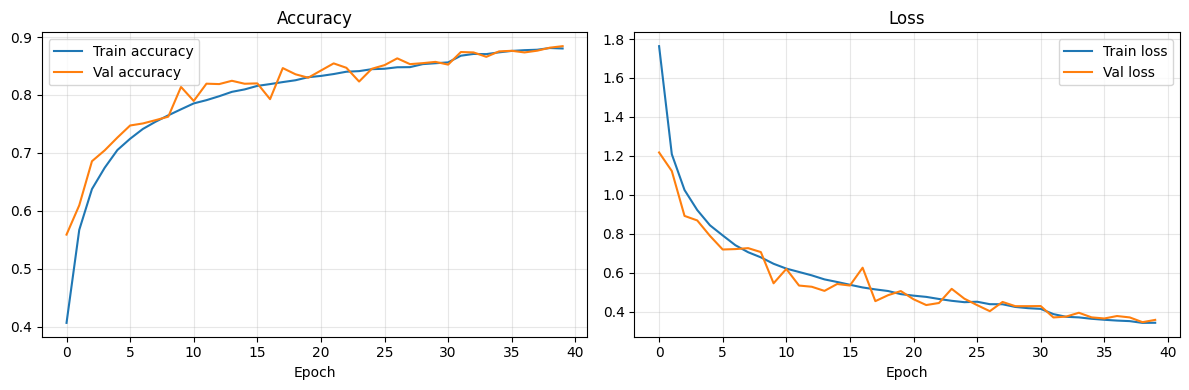

In [7]:
df = pd.DataFrame(history.history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df['accuracy'],     label='Train accuracy')
ax1.plot(df['val_accuracy'], label='Val accuracy')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(df['loss'],     label='Train loss')
ax2.plot(df['val_loss'], label='Val loss')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('history_plot.png', dpi=120, bbox_inches='tight')
plt.show()

## 7 — Evaluation

In [8]:
loss, accuracy = model.evaluate(x_test, y_test, verbose='auto')
print(f'Test loss:     {loss:.4f}')
print(f'Test accuracy: {accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8842 - loss: 0.3572
Test loss:     0.3572
Test accuracy: 0.8842


## 8 — Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


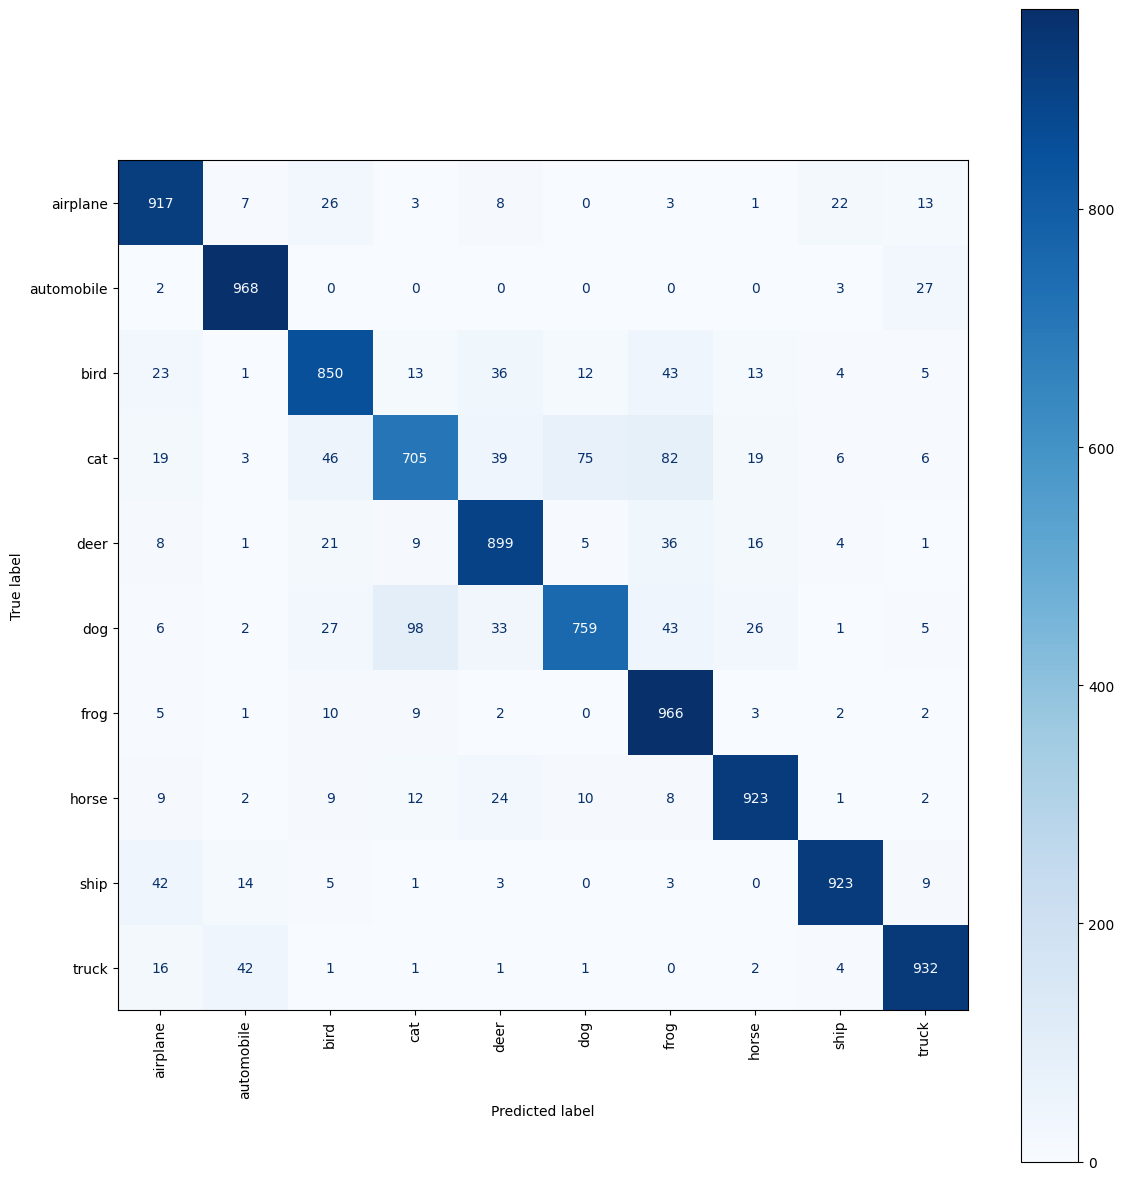

In [9]:
predictions = np.argmax(model.predict(x_test), axis=1)
y_true      = np.argmax(y_test, axis=1)

cm   = confusion_matrix(y_true, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(xticks_rotation='vertical', ax=ax, cmap='Blues')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 9 — Misclassified Examples

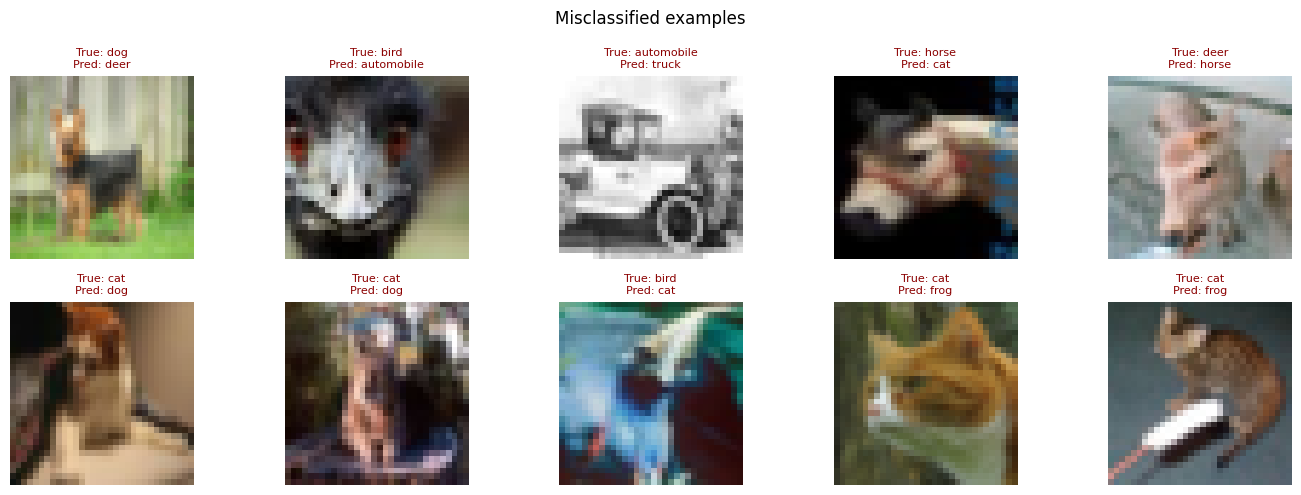

In [10]:
N_SHOW  = 10
incorrect = np.nonzero(predictions != y_true)[0]
n = min(N_SHOW, len(incorrect))

fig, axes = plt.subplots(2, n // 2, figsize=(14, 5))
for ax, idx in zip(axes.flat, incorrect[:n]):
    ax.imshow(x_test[idx])
    ax.set_title(
        f'True: {LABELS[y_true[idx]]}\nPred: {LABELS[predictions[idx]]}',
        fontsize=8, color='darkred'
    )
    ax.axis('off')
plt.suptitle('Misclassified examples', fontsize=12)
plt.tight_layout()
plt.show()

## 10 — Save Model

In [11]:
model.save('cifar10_model.keras')
print('Model saved to cifar10_model.keras')

Model saved to cifar10_model.keras
